In [7]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from simple_synth import SimpleSynth
import scipy
import matplotlib
import matplotlib.pyplot as plt
from src.model.utils import general_power_transform

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


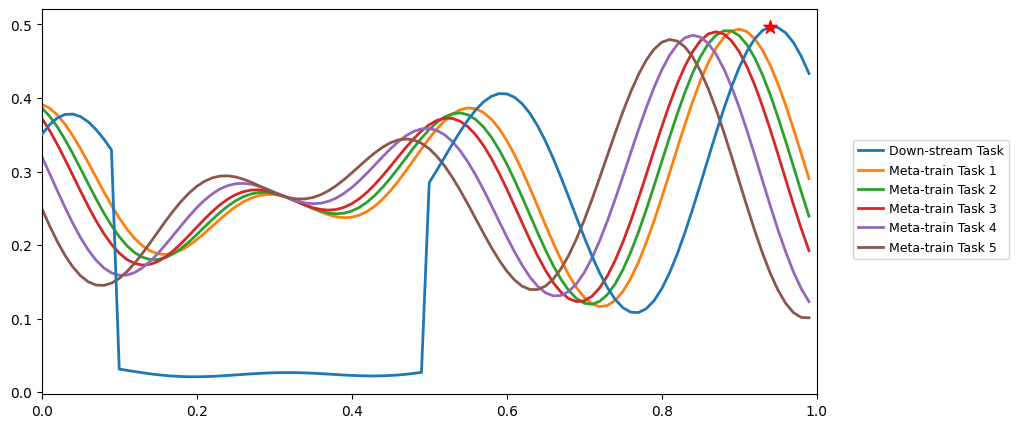

In [11]:
test_seed = "test2"
task_id = 0  # Task ID for the SimpleSynth benchmark
max_evaluations = 20
fontsize = 18
lw=2


seed_num = int(''.join(filter(str.isdigit, test_seed)))
torch.manual_seed(seed_num)
np.random.seed(seed_num)
random.seed(seed_num)

benchmark = SimpleSynth(seed=test_seed, start_task=task_id, initializations=2)
#meta_data = benchmark.get_meta_data(task_ids=[3, 4, 5, 7, 11])
meta_data = benchmark.get_meta_data()
X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
y = 1 - y
data_size = len(X)
init_ids = benchmark.bo_initializations[test_seed]

fig, ax = plt.subplots(figsize=(10, 5))

not_init = np.setdiff1d(np.arange(data_size), init_ids)
ax.plot(X[not_init], 1 - y[not_init], linewidth=lw, label="Down-stream Task", zorder = 99)
ax.scatter([X[y.argmin()]], [1 - y.min()], marker="*", s=100, c= "red", zorder = 99)

task_names = ["Meta-train Task 1", "Meta-train Task 2", "Meta-train Task 3", "Meta-train Task 4", "Meta-train Task 5"]

for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        ax.plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i])

ax.set_xlim(0,1)


lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]


anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels,loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.5,  handletextpad=0.5, labelspacing = 0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)

Iteration 1/20, Current best: 0.6428, 


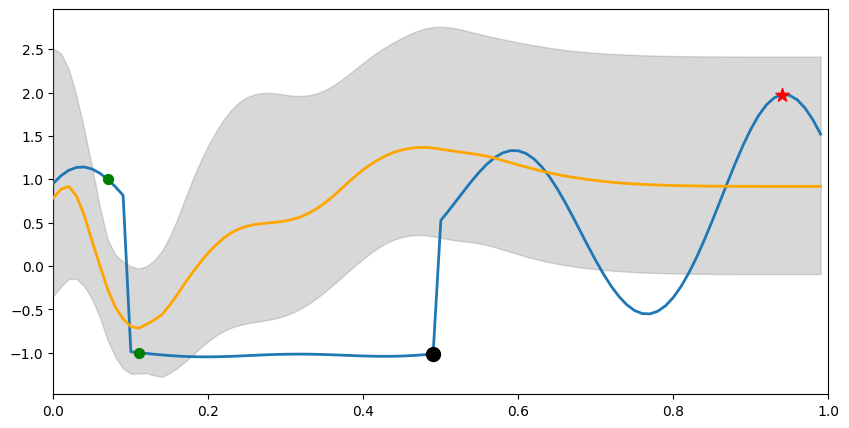

Iteration 2/20, Current best: 0.6428, 


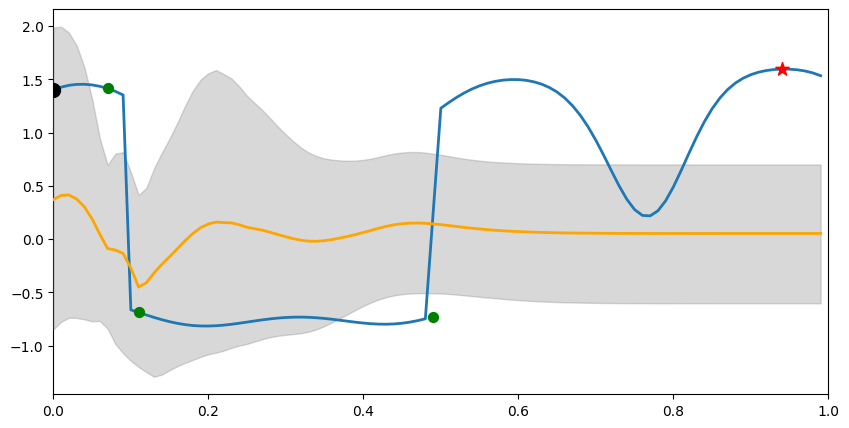

Iteration 3/20, Current best: 0.6225, 


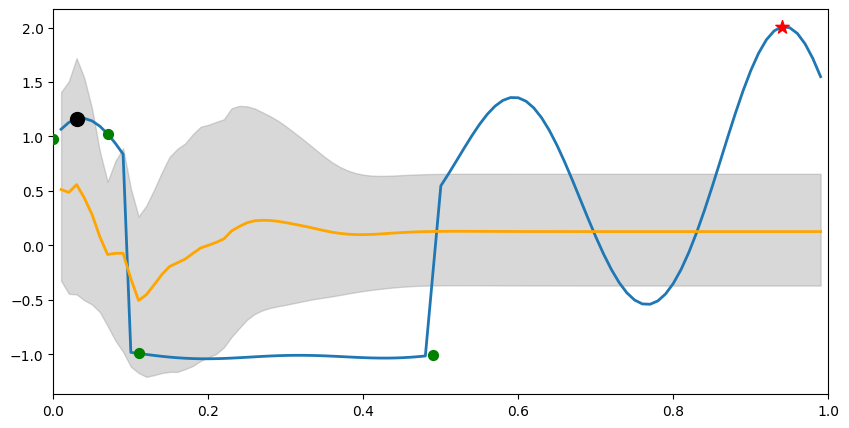

Iteration 4/20, Current best: 0.6225, 


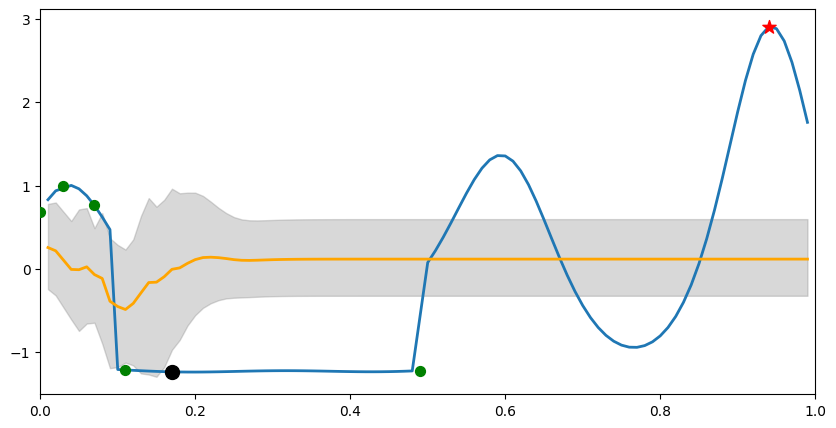

KeyboardInterrupt: 

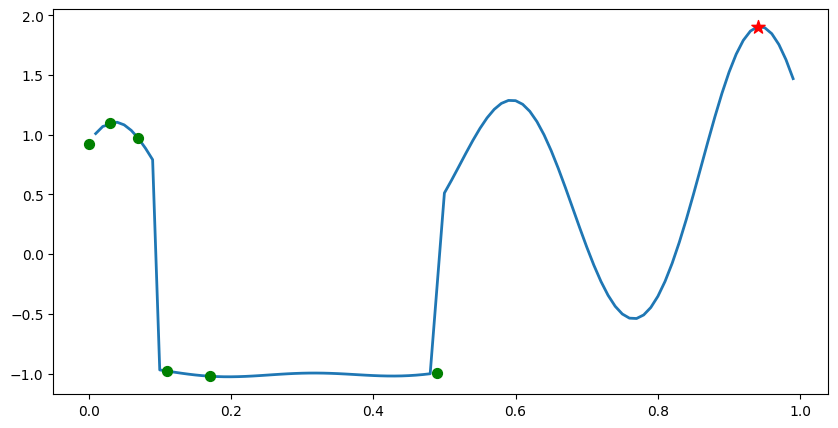

In [13]:
import pfns4bo
from mpfns4bo.aggregatedPFNs4bo import AggregatedPPFNs4BO
from mpfns4bo.tune_input_warping import fit_input_warping
apply_power_transform = True
apply_power_transform_ds = True
optimizer = AggregatedPPFNs4BO(torch.load( pfns4bo.hebo_plus_model), benchmark.search_space, meta_data,
 fit_encoder=fit_input_warping, apply_power_transform=apply_power_transform, apply_power_transform_ds=apply_power_transform_ds)

data_size = len(X)
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)

not_init = np.setdiff1d(np.arange(data_size), init_ids)


min_regret_history = [np.min(y[current_evaluations])]
opt_time = []
for iteration in range(max_evaluations):
    fig, ax = plt.subplots(figsize=(10, 5))
    task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]
    if apply_power_transform:
        y_t = general_power_transform(y[current_evaluations], y)
    else:
        y_t = y


    not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
    ax.plot(X[not_evaluated], - y_t[not_evaluated], linewidth=lw, label="Down Stream Task", zorder = 99)
    ax.scatter([X[y.argmin()]], [ - y_t.min()], marker="*", s=100, c= "red", zorder = 99)
    ax.scatter(X[current_evaluations],  - y_t[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)
    idx = optimizer.observe_and_suggest(
        X[current_evaluations], y[current_evaluations], X[pending_evaluations]
    )

    ax.scatter(X[pending_evaluations][idx], - y_t[pending_evaluations][idx], s= 100, c= "black", label="Next Sample (with meta learning)", zorder = 99)
    median = optimizer.model.criterion.median(optimizer.target_logits)

    # Plot median as a line
    ax.plot(X[pending_evaluations].squeeze(), median[:, 0], color="orange", label="Median", linewidth=lw, zorder=99)

    # median = optimizer.model.criterion.median(optimizer.meta_logits[2*len(current_evaluations):, 0])
    # ax.plot(X[pending_evaluations].squeeze(), median, color="red", label="Median", linewidth=lw, zorder=99)

    quantiles = optimizer.model.criterion.quantile(optimizer.target_logits, center_prob=0.75)
    # Plot confidence interval as a shaded area
    ax.fill_between(
        X[pending_evaluations].squeeze(),
        quantiles[:, 0, 1],
        quantiles[:, 0, 0],
        color="gray",
        alpha=0.3,
        label="Confidence Interval",
        zorder=98
    )
    ax.set_xlim(0, 1)


    idx = pending_evaluations[idx]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)
    min_regret_history.append(np.min(y[current_evaluations]))



    print(f"Iteration {iteration + 1}/{max_evaluations}, "
            f"Current best: {min_regret_history[-1]:.4f}, ")

    plt.show()


    if min(y) in min_regret_history:
        break

# negate to recover accuracy
min_regret_history += [min(y).item()] * (max_evaluations - i - 1)